In [1]:
import phoenix
import json

In [16]:
ham = phoenix.Hamiltonian(['XXXXXXI', 'IIIIIIZ'])
local_ham, nonlocal_ham = ham.separate_local_nonlocal()

In [17]:
nonlocal_ham.total_weight

6

In [18]:
nonlocal_ham.print_tableau()

+---------------------------------------------+
|            Display index: q0...q6           |
+---------+---------------+---------------+---+
|  Pauli  |     X part    |     Z part    | s |
+---------+---------------+---------------+---+
| IXXXXXX | 0 1 1 1 1 1 1 | 0 0 0 0 0 0 0 | 0 |
+---------+---------------+---------------+---+


In [20]:
ham.active_qubits

array([0, 1, 2, 3, 4, 5, 6])

In [21]:
nonlocal_ham.active_qubits

array([1, 2, 3, 4, 5, 6])

### `discreteoptimization` category

In [2]:
fname = '../benchmarks/hamlib_json/discreteoptimization/TSP_Ncity-10-tsp_prob-pr76_Ncity-10_enc-unary.json'
fname = '../benchmarks/hamlib_json/discreteoptimization/TSP_Ncity-8-tsp_prob-ulysses22_Ncity-8_enc-stdbinary.json'
with open(fname, 'r') as f:
    data = json.load(f)
ham = phoenix.Hamiltonian(data['paulis'], data['coeffs'])

In [3]:
!python pauli_stats.py ../benchmarks/hamlib_json/discreteoptimization/TSP_Ncity-10-tsp_prob-pr76_Ncity-10_enc-unary.json

Loaded ../benchmarks/hamlib_json/discreteoptimization/TSP_Ncity-10-tsp_prob-pr76_Ncity-10_enc-unary.json in 0.00 seconds.
Number of Paulis: 1000
Number of Qubits: 100
Grouped paulis in 0.05 seconds.
Number of groups: 1000
Group weights: Counter({2: 900, 1: 100})
Group sizes: Counter({1: 1000})


In [4]:
qc = phoenix.compile_hamiltonian_simulation(ham)

Total 448 Hamiltonian groups after grouping by weight.
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 6
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weight of the Hamiltonian group: 5
max_weigh

In [5]:
qc0 = ham.generate_circuit()

In [6]:
phoenix.utils.print_circ_info(qc0, "Original circuit")
phoenix.utils.print_circ_info(qc, "Compiled circuit")

+----------------------------------------------------------+
|                     Original circuit                     |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     24     |    2240   |     1888     |  2052 |   1741   |
+------------+-----------+--------------+-------+----------+
+----------------------------------------------------------+
|                     Compiled circuit                     |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     24     |    3330   |     1102     |  1039 |   519    |
+------------+-----------+--------------+-------+----------+


In [7]:
phoenix.utils.print_circ_info(phoenix.utils.tket_pass(ham.paulis.to_labels(), ham.coeffs), "Tket pass")

+----------------------------------------------------------+
|                        Tket pass                         |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     24     |    983    |     529      |  267  |   160    |
+------------+-----------+--------------+-------+----------+


/Users/anan/git-projects/quantum/phoenix/phoenix/utils.py:185: ComplexWarning: Casting complex values to real discards the imaginary part
  pauli_box = PauliExpBox([pauli_str_map[pauli[q]] for q in qubits], t=coeff * 2 / np.pi)


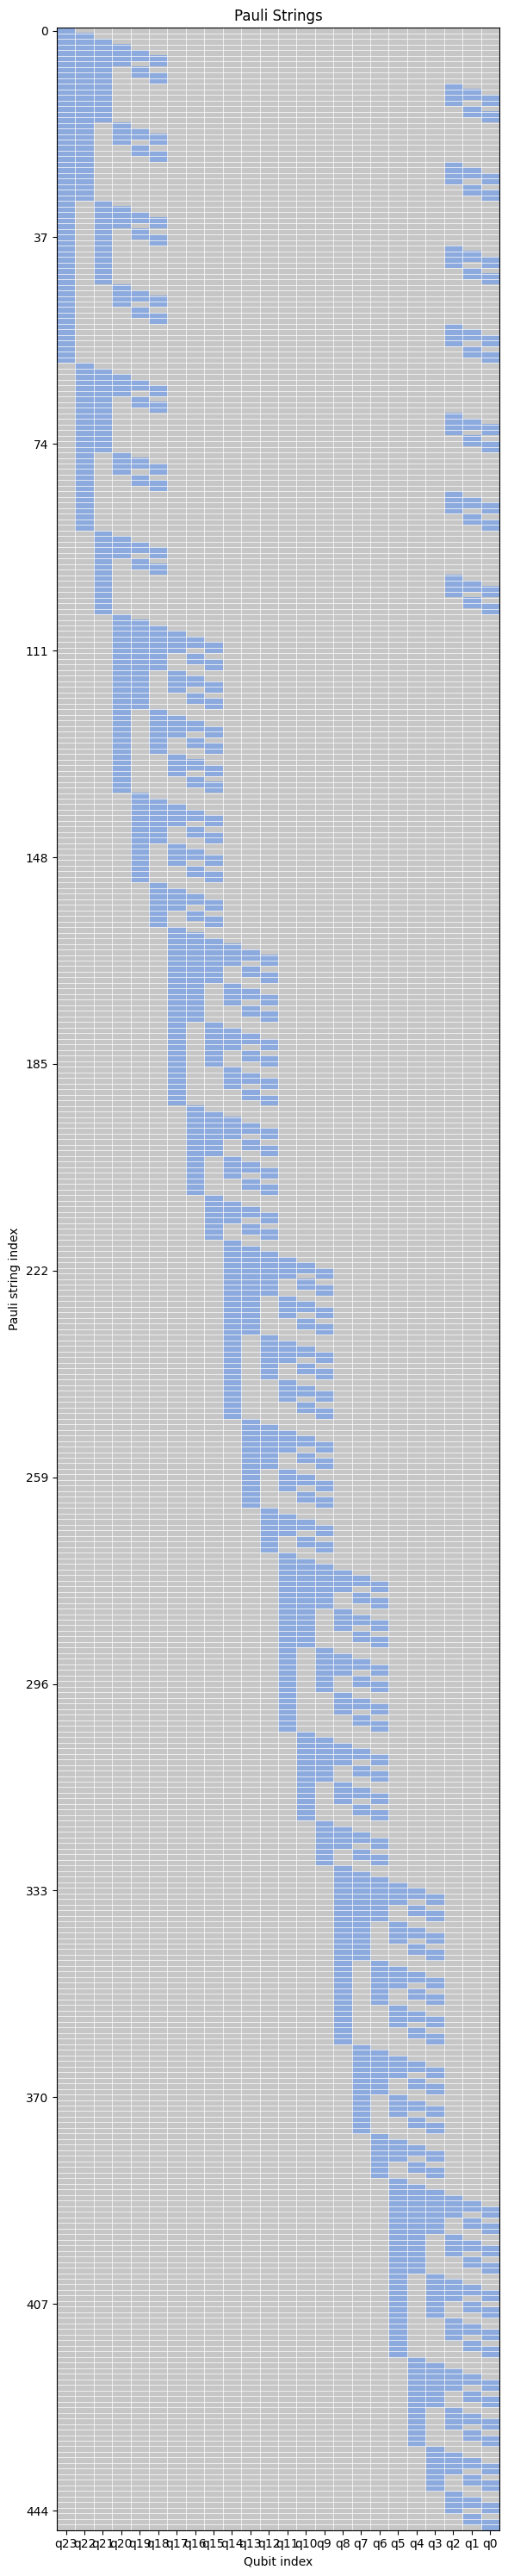

In [8]:
phoenix.utils.plot_pauli_strings(ham.paulis.to_labels(), figsize=(6, 30))

In [9]:
fname = '../benchmarks/hamlib_json/condensedmatter/FH_D-2-fh-graph-2D-grid-pbc-qubitnodes_Lx-5_Ly-72_U-0_enc-parity.json'
with open(fname, 'r') as f:
    data = json.load(f)
ham = phoenix.Hamiltonian(data['paulis'], data['coeffs'])

In [10]:
groups = ham.group_same_weights()

In [15]:
groups[1].print_tableau()

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [45]:
from itertools import chain

ham_new = phoenix.Hamiltonian(list(chain.from_iterable([h.paulis.to_labels() for h in groups[:10]])))

In [50]:
phoenix.utils.plot_pauli_strings(ham_new.paulis.to_labels(), figsize=(300, 20))

In [51]:
ham_new.print_tableau()

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------